In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 데이터 로드 (여기서는 CSV 파일을 사용한다고 가정)
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/recommenders/data_mf_5.csv')
df.drop(columns=['Unnamed: 0'], inplace=True)
df.rename(columns={'userId':'userID', 'movieId':'itemID','rating_new':'rating'},inplace=True)

# 암묵적 피드백으로 변환 (rating_new > 0은 positive interaction)
df['interaction'] = (df['rating'] > 0).astype(int)

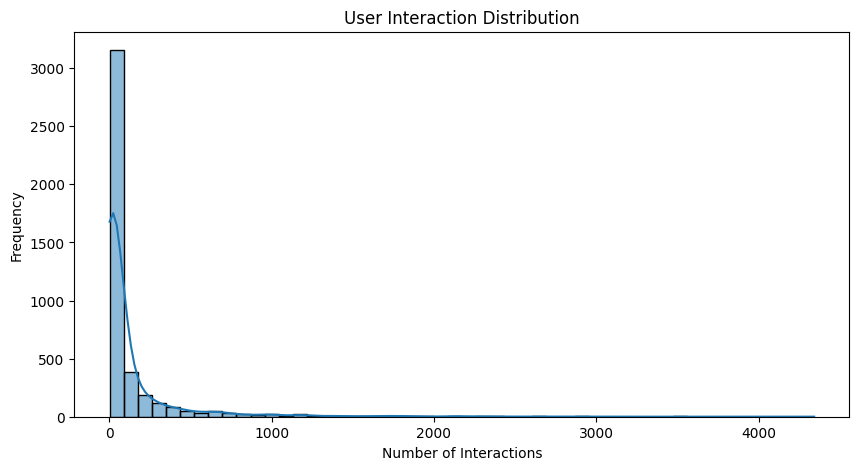

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 사용자별 interaction 횟수 계산
user_interactions = df.groupby('userID')['interaction'].sum()

# 아이템별 interaction 횟수 계산
item_interactions = df.groupby('itemID')['interaction'].sum()

# 사용자별 interaction 분포 시각화
plt.figure(figsize=(10, 5))
sns.histplot(user_interactions, bins=50, kde=True)
plt.title("User Interaction Distribution")
plt.xlabel("Number of Interactions")
plt.ylabel("Frequency")
plt.show()

In [9]:
# userID별 interaction 합계 계산
interaction_sum = df.groupby('userID')['interaction'].sum()

# 최빈값 계산
mode_value = interaction_sum.mode()[0]  # mode()는 리스트 형태로 반환됨, 첫 번째 값 선택
print("최빈값:", mode_value)

최빈값: 4


In [10]:
print(user_interactions.describe())

count    4253.000000
mean      128.199154
std       326.567298
min         1.000000
25%         6.000000
50%        18.000000
75%        92.000000
max      4343.000000
Name: interaction, dtype: float64


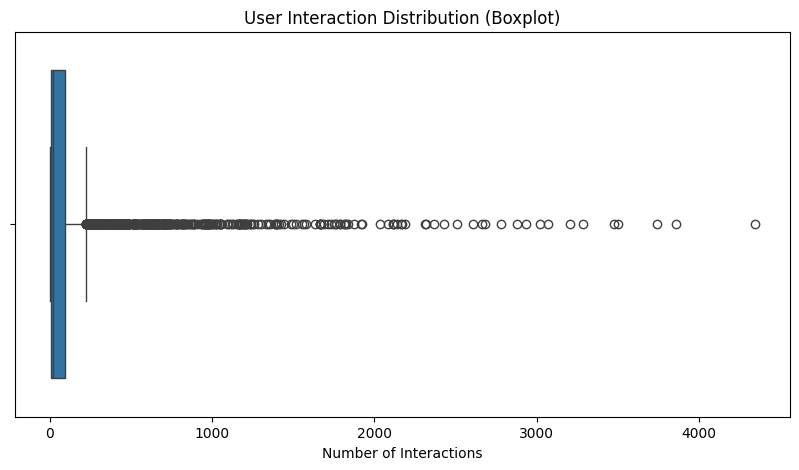

In [4]:
# 사용자별 interaction 분포 상자그림
plt.figure(figsize=(10, 5))
sns.boxplot(x=user_interactions)
plt.title("User Interaction Distribution (Boxplot)")
plt.xlabel("Number of Interactions")
plt.show()

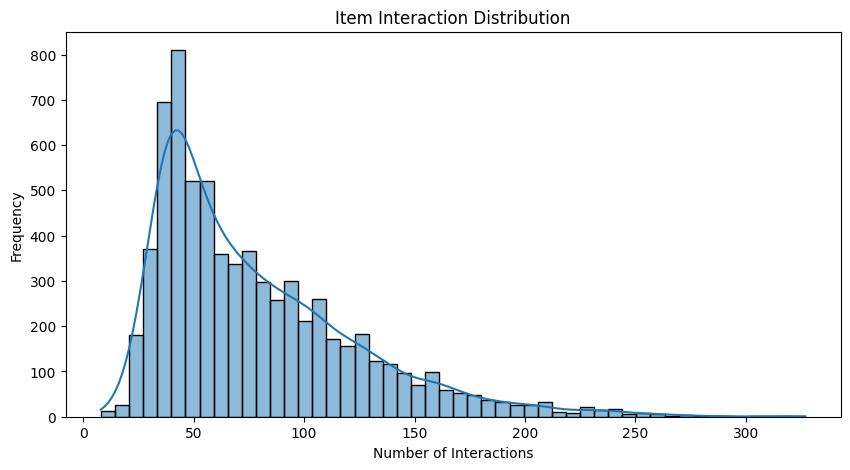

In [3]:
# 아이템별 interaction 분포 시각화
plt.figure(figsize=(10, 5))
sns.histplot(item_interactions, bins=50, kde=True)
plt.title("Item Interaction Distribution")
plt.xlabel("Number of Interactions")
plt.ylabel("Frequency")
plt.show()

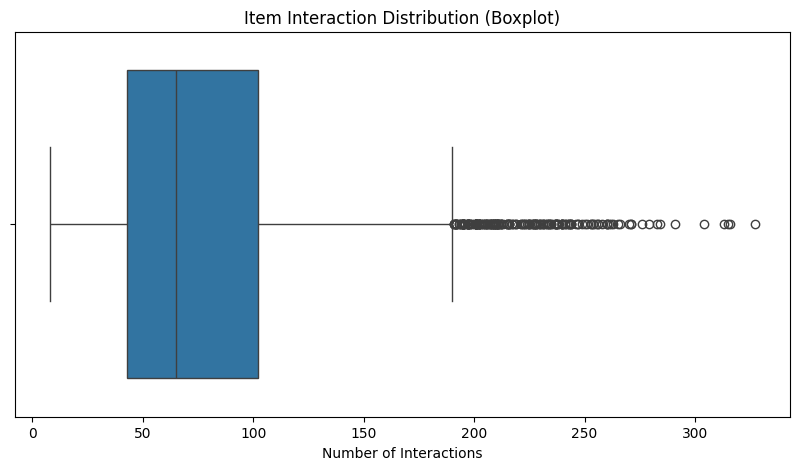

In [5]:
# 아이템별 interaction 분포 상자그림
plt.figure(figsize=(10, 5))
sns.boxplot(x=item_interactions)
plt.title("Item Interaction Distribution (Boxplot)")
plt.xlabel("Number of Interactions")
plt.show()

In [1]:
!pip install recommenders

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.4/316.4 kB 10.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 4.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 356.0/356.0 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.0/82.0 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21.3 MB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 91.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.0/261.0 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import sys
import os
import pandas as pd
import numpy as np
import tensorflow as tf
tf.get_logger().setLevel('ERROR') # only show error messages

from recommenders.utils.timer import Timer
from recommenders.models.deeprec.models.graphrec.lightgcn import LightGCN
from recommenders.models.deeprec.DataModel.ImplicitCF import ImplicitCF
from recommenders.datasets.python_splitters import python_stratified_split
from recommenders.evaluation.python_evaluation import map, ndcg_at_k, precision_at_k, recall_at_k
from recommenders.utils.constants import SEED as DEFAULT_SEED
from recommenders.models.deeprec.deeprec_utils import prepare_hparams
from recommenders.utils.notebook_utils import store_metadata

print(f"System version: {sys.version}")
print(f"Pandas version: {pd.__version__}")
print(f"Tensorflow version: {tf.__version__}")

System version: 3.10.12 (main, Nov  6 2024, 20:22:13) [GCC 11.4.0]
Pandas version: 2.2.2
Tensorflow version: 2.17.1


In [3]:
# # top k items to recommend
# TOP_K = 10
# # Model parameters
# EPOCHS = 50
# BATCH_SIZE = 1024

SEED = 2024  # Set None for non-deterministic results

In [5]:
import pandas as pd
from recommenders.datasets.python_splitters import python_stratified_split

# 데이터 로드 (여기서는 CSV 파일을 사용한다고 가정)
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/recommenders/data_mf_5.csv')
df.drop(columns=['Unnamed: 0'], inplace=True)
df.rename(columns={'userId':'userID', 'movieId':'itemID','rating_new':'rating'},inplace=True)

# 암묵적 피드백으로 변환 (rating_new > 0은 positive interaction)
df['interaction'] = (df['rating'] > 0).astype(int)

# train-test split
train, test = python_stratified_split(df, ratio=0.75, col_user='userID', col_item='itemID')

In [6]:
from recommenders.models.deeprec.DataModel.ImplicitCF import ImplicitCF

# ImplicitCF 데이터 생성
data = ImplicitCF(train=train, test=test, seed=42)

In [12]:
data

In [27]:
from recommenders.models.deeprec.deeprec_utils import prepare_hparams
from recommenders.models.deeprec.models.graphrec.lightgcn import LightGCN

hparams = prepare_hparams(
    yaml_file=None,
    model_type="lightgcn",
    n_layers=3,
    batch_size=1024,
    epochs=200,
    learning_rate=0.001,
    top_k=20,
    embed_size=64,
    decay=0.0001,  # L2 정규화 계수
    eval_epoch =20,
    metrics=["recall", "ndcg", "precision", "map"],
    MODEL_DIR="/content/drive/MyDrive/Colab Notebooks/recommenders/model_dir/3"
)

''' --> 코드 내 yaml 파일 인자
#model
model:
    model_type : "lightgcn"
    embed_size : 64 # the embedding dimension of users and items
    n_layers : 3 # number of layers of the model

#train
train:
    batch_size : 1024
    decay : 0.0001 # l2 regularization for embedding parameters
    epochs : 1000 # number of epochs for training
    learning_rate : 0.001
    eval_epoch : -1 # if it is not -1, evaluate the model every eval_epoch; -1 means that evaluation will not be performed during training
    top_k : 20 # number of items to recommend when calculating evaluation metrics
'''

from recommenders.models.deeprec.models.graphrec.lightgcn import LightGCN

# 모델 초기화
model = LightGCN(hparams, data, seed=42)

Already create adjacency matrix.
Already normalize adjacency matrix.
Using xavier initialization.


In [28]:
# 모델 학습
with Timer() as train_time:
    model.fit()

print("Took {} seconds for training.".format(train_time.interval))

Epoch 1 (train)7.9s: train loss = 0.57232 = (mf)0.57216 + (embed)0.00016
Epoch 2 (train)7.1s: train loss = 0.39620 = (mf)0.39559 + (embed)0.00060
Epoch 3 (train)7.6s: train loss = 0.33434 = (mf)0.33345 + (embed)0.00089
Epoch 4 (train)7.6s: train loss = 0.29277 = (mf)0.29164 + (embed)0.00113
Save model to path /content/drive/MyDrive/Colab Notebooks/recommenders/model_dir/3/epoch_5
Epoch 5 (train)7.6s: train loss = 0.26700 = (mf)0.26564 + (embed)0.00136
Epoch 6 (train)8.0s: train loss = 0.25159 = (mf)0.25004 + (embed)0.00155
Epoch 7 (train)6.4s: train loss = 0.23771 = (mf)0.23599 + (embed)0.00172
Epoch 8 (train)7.2s: train loss = 0.22758 = (mf)0.22569 + (embed)0.00189
Epoch 9 (train)6.6s: train loss = 0.21792 = (mf)0.21587 + (embed)0.00205
Save model to path /content/drive/MyDrive/Colab Notebooks/recommenders/model_dir/3/epoch_10
Epoch 10 (train)8.3s: train loss = 0.20898 = (mf)0.20677 + (embed)0.00221
Epoch 11 (train)7.5s: train loss = 0.20062 = (mf)0.19826 + (embed)0.00237
Epoch 12 (tr

/usr/local/lib/python3.10/dist-packages/recommenders/evaluation/python_evaluation.py:438: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  df_hit.groupby(col_user, as_index=False)[col_user].agg({"hit": "count"}),
/usr/local/lib/python3.10/dist-packages/recommenders/evaluation/python_evaluation.py:439: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  rating_true_common.groupby(col_user, as_index=False)[col_user].agg(


Epoch 20 (train)6.3s + (eval)2.5s: train loss = 0.14268 = (mf)0.13886 + (embed)0.00382, recall = 0.06269, ndcg = 0.08634, precision = 0.06667, map = 0.04218
Epoch 21 (train)7.8s: train loss = 0.13903 = (mf)0.13506 + (embed)0.00398
Epoch 22 (train)6.6s: train loss = 0.13409 = (mf)0.12996 + (embed)0.00413
Epoch 23 (train)6.7s: train loss = 0.12890 = (mf)0.12461 + (embed)0.00429
Epoch 24 (train)6.5s: train loss = 0.12649 = (mf)0.12205 + (embed)0.00444
Save model to path /content/drive/MyDrive/Colab Notebooks/recommenders/model_dir/3/epoch_25
Epoch 25 (train)6.8s: train loss = 0.12279 = (mf)0.11821 + (embed)0.00458
Epoch 26 (train)7.2s: train loss = 0.11995 = (mf)0.11523 + (embed)0.00473
Epoch 27 (train)6.9s: train loss = 0.11695 = (mf)0.11208 + (embed)0.00487
Epoch 28 (train)6.9s: train loss = 0.11463 = (mf)0.10962 + (embed)0.00501
Epoch 29 (train)6.4s: train loss = 0.11159 = (mf)0.10644 + (embed)0.00514
Save model to path /content/drive/MyDrive/Colab Notebooks/recommenders/model_dir/3/ep

/usr/local/lib/python3.10/dist-packages/recommenders/evaluation/python_evaluation.py:438: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  df_hit.groupby(col_user, as_index=False)[col_user].agg({"hit": "count"}),
/usr/local/lib/python3.10/dist-packages/recommenders/evaluation/python_evaluation.py:439: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  rating_true_common.groupby(col_user, as_index=False)[col_user].agg(


Epoch 40 (train)7.1s + (eval)2.0s: train loss = 0.09119 = (mf)0.08474 + (embed)0.00646, recall = 0.08425, ndcg = 0.11074, precision = 0.08251, map = 0.05692
Epoch 41 (train)7.4s: train loss = 0.09074 = (mf)0.08417 + (embed)0.00656
Epoch 42 (train)6.4s: train loss = 0.08825 = (mf)0.08158 + (embed)0.00667
Epoch 43 (train)6.9s: train loss = 0.08774 = (mf)0.08097 + (embed)0.00677
Epoch 44 (train)6.4s: train loss = 0.08734 = (mf)0.08048 + (embed)0.00686
Save model to path /content/drive/MyDrive/Colab Notebooks/recommenders/model_dir/3/epoch_45
Epoch 45 (train)6.7s: train loss = 0.08527 = (mf)0.07831 + (embed)0.00696
Epoch 46 (train)7.1s: train loss = 0.08488 = (mf)0.07784 + (embed)0.00704
Epoch 47 (train)7.1s: train loss = 0.08302 = (mf)0.07587 + (embed)0.00714
Epoch 48 (train)6.2s: train loss = 0.08255 = (mf)0.07533 + (embed)0.00722
Epoch 49 (train)7.1s: train loss = 0.08230 = (mf)0.07499 + (embed)0.00731
Save model to path /content/drive/MyDrive/Colab Notebooks/recommenders/model_dir/3/ep

...

Epoch 160 (train)6.3s + (eval)2.3s: train loss = 0.04853 = (mf)0.03706 + (embed)0.01147, recall = 0.09415, ndcg = 0.12579, precision = 0.09390, map = 0.06526
Epoch 161 (train)7.5s: train loss = 0.04819 = (mf)0.03670 + (embed)0.01149
Epoch 162 (train)7.1s: train loss = 0.04858 = (mf)0.03707 + (embed)0.01151
Epoch 163 (train)6.6s: train loss = 0.04781 = (mf)0.03628 + (embed)0.01153
Epoch 164 (train)6.6s: train loss = 0.04813 = (mf)0.03658 + (embed)0.01155
Save model to path /content/drive/MyDrive/Colab Notebooks/recommenders/model_dir/3/epoch_165
Epoch 165 (train)6.7s: train loss = 0.04796 = (mf)0.03639 + (embed)0.01157
Epoch 166 (train)7.8s: train loss = 0.04767 = (mf)0.03609 + (embed)0.01159
Epoch 167 (train)6.2s: train loss = 0.04790 = (mf)0.03629 + (embed)0.01161
Epoch 168 (train)7.0s: train loss = 0.04767 = (mf)0.03604 + (embed)0.01162
Epoch 169 (train)6.2s: train loss = 0.04739 = (mf)0.03575 + (embed)0.01164
Save model to path /content/drive/MyDrive/Colab Notebooks/recommenders/mod

/usr/local/lib/python3.10/dist-packages/recommenders/evaluation/python_evaluation.py:438: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  df_hit.groupby(col_user, as_index=False)[col_user].agg({"hit": "count"}),
/usr/local/lib/python3.10/dist-packages/recommenders/evaluation/python_evaluation.py:439: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  rating_true_common.groupby(col_user, as_index=False)[col_user].agg(


Epoch 180 (train)7.3s + (eval)2.2s: train loss = 0.04602 = (mf)0.03417 + (embed)0.01185, recall = 0.09766, ndcg = 0.12856, precision = 0.09546, map = 0.06671
Epoch 181 (train)7.5s: train loss = 0.04612 = (mf)0.03426 + (embed)0.01186
Epoch 182 (train)6.3s: train loss = 0.04667 = (mf)0.03479 + (embed)0.01188
Epoch 183 (train)6.9s: train loss = 0.04630 = (mf)0.03440 + (embed)0.01190
Epoch 184 (train)6.3s: train loss = 0.04625 = (mf)0.03433 + (embed)0.01191
Save model to path /content/drive/MyDrive/Colab Notebooks/recommenders/model_dir/3/epoch_185
Epoch 185 (train)6.8s: train loss = 0.04573 = (mf)0.03380 + (embed)0.01193
Epoch 186 (train)6.8s: train loss = 0.04600 = (mf)0.03405 + (embed)0.01195
Epoch 187 (train)7.4s: train loss = 0.04593 = (mf)0.03397 + (embed)0.01196
Epoch 188 (train)6.2s: train loss = 0.04614 = (mf)0.03415 + (embed)0.01198
Epoch 189 (train)7.0s: train loss = 0.04550 = (mf)0.03350 + (embed)0.01200
Save model to path /content/drive/MyDrive/Colab Notebooks/recommenders/mod

/usr/local/lib/python3.10/dist-packages/recommenders/evaluation/python_evaluation.py:438: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  df_hit.groupby(col_user, as_index=False)[col_user].agg({"hit": "count"}),
/usr/local/lib/python3.10/dist-packages/recommenders/evaluation/python_evaluation.py:439: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  rating_true_common.groupby(col_user, as_index=False)[col_user].agg(


Epoch 200 (train)6.3s + (eval)2.7s: train loss = 0.04558 = (mf)0.03340 + (embed)0.01218, recall = 0.09730, ndcg = 0.12849, precision = 0.09525, map = 0.06670
Took 1452.1834828199999 seconds for training.


In [51]:
# LightGCN 모델 학습 후 평가 코드
from recommenders.evaluation.python_evaluation import map, ndcg_at_k, precision_at_k, recall_at_k

# 추천 결과 생성
TOP_K = 20  # 추천받을 Top-K 아이템 수를 지정
topk_scores = model.recommend_k_items(test, top_k=TOP_K, remove_seen=True)

# 평가 지표 계산
eval_map = map(test, topk_scores, k=TOP_K)
eval_ndcg = ndcg_at_k(test, topk_scores, k=TOP_K)
eval_precision = precision_at_k(test, topk_scores, k=TOP_K)
eval_recall = recall_at_k(test, topk_scores, k=TOP_K)

# 결과 출력
print(f"Evaluation Metrics (Top-{TOP_K}):")
print(f"MAP:\t\t{eval_map:.6f}")
print(f"NDCG:\t\t{eval_ndcg:.6f}")
print(f"Precision@K:\t{eval_precision:.6f}")
print(f"Recall@K:\t{eval_recall:.6f}")

/usr/local/lib/python3.10/dist-packages/recommenders/evaluation/python_evaluation.py:438: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  df_hit.groupby(col_user, as_index=False)[col_user].agg({"hit": "count"}),
/usr/local/lib/python3.10/dist-packages/recommenders/evaluation/python_evaluation.py:439: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  rating_true_common.groupby(col_user, as_index=False)[col_user].agg(


Evaluation Metrics (Top-20):
MAP:		0.030218
NDCG:		0.128712
Precision@K:	0.095399
Recall@K:	0.097764


In [44]:
test

,userID,itemID,rating,interaction
375206,1,4775,2.000,1
399217,1,5085,3.000,1
287561,1,3672,2.500,1
123998,1,1599,3.000,1
131211,1,1691,2.000,1
...,...,...,...,...
414138,4552,5286,2.000,1
398175,4553,5073,4.375,1
430854,4562,5496,4.000,1
492303,4598,6290,3.000,1


In [50]:
test[(test['userID'] == 1)&(test['itemID'] == 5838)]

,userID,itemID,rating,interaction


In [ ]:
test['itemID'] == 6648

In [42]:
topk_scores

,userID,itemID,prediction
0,1,5947,5.815662
1,1,6648,5.567604
2,1,6600,5.566517
3,1,2443,5.549603
4,1,5838,5.520569
5,1,5852,5.455204
6,1,4045,5.302842
7,1,6188,5.280396
8,1,6187,5.248677
9,1,5015,5.248336


In [53]:
df

,userID,itemID,rating,interaction,random
0,1,1,3.000,1,0.374540
1,2,1,3.000,1,0.950714
2,4,1,3.500,1,0.731994
3,8,1,3.000,1,0.598658
4,9,1,3.000,1,0.156019
...,...,...,...,...,...
547891,899,6963,3.500,1,0.450421
547892,857,6963,4.000,1,0.285096
547893,3683,6963,4.000,1,0.980349
547894,930,6963,1.250,1,0.347486


# 3try

In [20]:
from recommenders.models.deeprec.deeprec_utils import prepare_hparams
from recommenders.models.deeprec.models.graphrec.lightgcn import LightGCN

hparams = prepare_hparams(
    yaml_file=None,
    model_type="lightgcn",
    n_layers=3,
    batch_size=1024,
    epochs=50,
    learning_rate=0.001,
    top_k=20,
    embed_size=64,
    decay=1e-4,  # L2 정규화 계수
    eval_epoch =10,
     metrics=["recall", "ndcg", "precision", "map"],
    MODEL_DIR="/content/drive/MyDrive/Colab Notebooks/recommenders/model_dir/2"
)

from recommenders.models.deeprec.models.graphrec.lightgcn import LightGCN

# 모델 초기화
model = LightGCN(hparams, data, seed=42)

Already create adjacency matrix.
Already normalize adjacency matrix.
Using xavier initialization.


In [21]:
# 모델 학습
with Timer() as train_time:
    model.fit()

print("Took {} seconds for training.".format(train_time.interval))

Epoch 1 (train)7.5s: train loss = 0.57253 = (mf)0.57237 + (embed)0.00016
Epoch 2 (train)7.0s: train loss = 0.38916 = (mf)0.38855 + (embed)0.00062
Epoch 3 (train)6.3s: train loss = 0.32572 = (mf)0.32480 + (embed)0.00092
Epoch 4 (train)7.3s: train loss = 0.28911 = (mf)0.28795 + (embed)0.00116
Save model to path /content/drive/MyDrive/Colab Notebooks/recommenders/model_dir/2/epoch_5
Epoch 5 (train)6.3s: train loss = 0.26679 = (mf)0.26543 + (embed)0.00137
Epoch 6 (train)8.3s: train loss = 0.25169 = (mf)0.25014 + (embed)0.00155
Epoch 7 (train)6.2s: train loss = 0.23816 = (mf)0.23643 + (embed)0.00173
Epoch 8 (train)7.1s: train loss = 0.22759 = (mf)0.22570 + (embed)0.00189
Epoch 9 (train)6.3s: train loss = 0.22020 = (mf)0.21815 + (embed)0.00205
Save model to path /content/drive/MyDrive/Colab Notebooks/recommenders/model_dir/2/epoch_10


/usr/local/lib/python3.10/dist-packages/recommenders/evaluation/python_evaluation.py:438: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  df_hit.groupby(col_user, as_index=False)[col_user].agg({"hit": "count"}),
/usr/local/lib/python3.10/dist-packages/recommenders/evaluation/python_evaluation.py:439: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  rating_true_common.groupby(col_user, as_index=False)[col_user].agg(


Epoch 10 (train)7.2s + (eval)2.6s: train loss = 0.20984 = (mf)0.20763 + (embed)0.00221, recall = 0.04541, ndcg = 0.06552, precision = 0.05141, map = 0.02945
Epoch 11 (train)7.6s: train loss = 0.20105 = (mf)0.19868 + (embed)0.00237
Epoch 12 (train)7.4s: train loss = 0.19273 = (mf)0.19020 + (embed)0.00253
Epoch 13 (train)6.5s: train loss = 0.18496 = (mf)0.18226 + (embed)0.00270
Epoch 14 (train)7.0s: train loss = 0.17697 = (mf)0.17411 + (embed)0.00286
Save model to path /content/drive/MyDrive/Colab Notebooks/recommenders/model_dir/2/epoch_15
Epoch 15 (train)6.4s: train loss = 0.16958 = (mf)0.16655 + (embed)0.00303
Epoch 16 (train)7.2s: train loss = 0.16353 = (mf)0.16033 + (embed)0.00319
Epoch 17 (train)6.5s: train loss = 0.15657 = (mf)0.15321 + (embed)0.00336
Epoch 18 (train)6.9s: train loss = 0.15118 = (mf)0.14766 + (embed)0.00352
Epoch 19 (train)6.5s: train loss = 0.14599 = (mf)0.14230 + (embed)0.00369
Save model to path /content/drive/MyDrive/Colab Notebooks/recommenders/model_dir/2/ep

/usr/local/lib/python3.10/dist-packages/recommenders/evaluation/python_evaluation.py:438: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  df_hit.groupby(col_user, as_index=False)[col_user].agg({"hit": "count"}),
/usr/local/lib/python3.10/dist-packages/recommenders/evaluation/python_evaluation.py:439: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  rating_true_common.groupby(col_user, as_index=False)[col_user].agg(


Epoch 20 (train)7.3s + (eval)2.1s: train loss = 0.14157 = (mf)0.13772 + (embed)0.00385, recall = 0.06496, ndcg = 0.08808, precision = 0.06719, map = 0.04321
Epoch 21 (train)7.8s: train loss = 0.13651 = (mf)0.13251 + (embed)0.00400
Epoch 22 (train)6.3s: train loss = 0.13197 = (mf)0.12781 + (embed)0.00416
Epoch 23 (train)8.1s: train loss = 0.12894 = (mf)0.12462 + (embed)0.00431
Epoch 24 (train)6.5s: train loss = 0.12500 = (mf)0.12054 + (embed)0.00446
Save model to path /content/drive/MyDrive/Colab Notebooks/recommenders/model_dir/2/epoch_25
Epoch 25 (train)7.2s: train loss = 0.12131 = (mf)0.11671 + (embed)0.00461
Epoch 26 (train)6.6s: train loss = 0.11807 = (mf)0.11331 + (embed)0.00476
Epoch 27 (train)7.3s: train loss = 0.11506 = (mf)0.11016 + (embed)0.00490
Epoch 28 (train)6.6s: train loss = 0.11242 = (mf)0.10738 + (embed)0.00504
Epoch 29 (train)7.2s: train loss = 0.11032 = (mf)0.10514 + (embed)0.00517
Save model to path /content/drive/MyDrive/Colab Notebooks/recommenders/model_dir/2/ep

...

Epoch 30 (train)6.3s + (eval)2.8s: train loss = 0.10806 = (mf)0.10274 + (embed)0.00531, recall = 0.07574, ndcg = 0.10096, precision = 0.07632, map = 0.05057
Epoch 31 (train)6.9s: train loss = 0.10512 = (mf)0.09968 + (embed)0.00544
Epoch 32 (train)6.9s: train loss = 0.10377 = (mf)0.09820 + (embed)0.00557
Epoch 33 (train)6.5s: train loss = 0.10161 = (mf)0.09592 + (embed)0.00569
Epoch 34 (train)8.1s: train loss = 0.09859 = (mf)0.09277 + (embed)0.00581
Save model to path /content/drive/MyDrive/Colab Notebooks/recommenders/model_dir/2/epoch_35
Epoch 35 (train)6.3s: train loss = 0.09808 = (mf)0.09214 + (embed)0.00593
Epoch 36 (train)8.0s: train loss = 0.09637 = (mf)0.09032 + (embed)0.00605
Epoch 37 (train)6.3s: train loss = 0.09499 = (mf)0.08882 + (embed)0.00617
Epoch 38 (train)7.1s: train loss = 0.09263 = (mf)0.08636 + (embed)0.00627
Epoch 39 (train)6.2s: train loss = 0.09141 = (mf)0.08503 + (embed)0.00638
Save model to path /content/drive/MyDrive/Colab Notebooks/recommenders/model_dir/2/ep

/usr/local/lib/python3.10/dist-packages/recommenders/evaluation/python_evaluation.py:438: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  df_hit.groupby(col_user, as_index=False)[col_user].agg({"hit": "count"}),
/usr/local/lib/python3.10/dist-packages/recommenders/evaluation/python_evaluation.py:439: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  rating_true_common.groupby(col_user, as_index=False)[col_user].agg(


Epoch 40 (train)7.1s + (eval)2.0s: train loss = 0.09029 = (mf)0.08381 + (embed)0.00648, recall = 0.08469, ndcg = 0.10934, precision = 0.08268, map = 0.05510
Epoch 41 (train)6.7s: train loss = 0.08921 = (mf)0.08263 + (embed)0.00659
Epoch 42 (train)7.1s: train loss = 0.08851 = (mf)0.08183 + (embed)0.00668
Epoch 43 (train)6.2s: train loss = 0.08820 = (mf)0.08142 + (embed)0.00678
Epoch 44 (train)7.1s: train loss = 0.08557 = (mf)0.07869 + (embed)0.00688
Save model to path /content/drive/MyDrive/Colab Notebooks/recommenders/model_dir/2/epoch_45
Epoch 45 (train)6.6s: train loss = 0.08479 = (mf)0.07782 + (embed)0.00697
Epoch 46 (train)7.4s: train loss = 0.08466 = (mf)0.07761 + (embed)0.00705
Epoch 47 (train)6.4s: train loss = 0.08240 = (mf)0.07526 + (embed)0.00715
Epoch 48 (train)7.1s: train loss = 0.08198 = (mf)0.07475 + (embed)0.00723
Epoch 49 (train)6.2s: train loss = 0.08044 = (mf)0.07311 + (embed)0.00733
Save model to path /content/drive/MyDrive/Colab Notebooks/recommenders/model_dir/2/ep

/usr/local/lib/python3.10/dist-packages/recommenders/evaluation/python_evaluation.py:438: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  df_hit.groupby(col_user, as_index=False)[col_user].agg({"hit": "count"}),
/usr/local/lib/python3.10/dist-packages/recommenders/evaluation/python_evaluation.py:439: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  rating_true_common.groupby(col_user, as_index=False)[col_user].agg(


Epoch 50 (train)7.2s + (eval)2.0s: train loss = 0.07955 = (mf)0.07213 + (embed)0.00741, recall = 0.08812, ndcg = 0.11432, precision = 0.08647, map = 0.05802
Took 363.90604360099996 seconds for training.


In [22]:
topk_scores = model.recommend_k_items(test, top_k=TOP_K, remove_seen=True)
eval_map = map(test, topk_scores, k=TOP_K)
eval_ndcg = ndcg_at_k(test, topk_scores, k=TOP_K)
eval_precision = precision_at_k(test, topk_scores, k=TOP_K)
eval_recall = recall_at_k(test, topk_scores, k=TOP_K)

print("MAP:\t%f" % eval_map,
      "NDCG:\t%f" % eval_ndcg,
      "Precision@K:\t%f" % eval_precision,
      "Recall@K:\t%f" % eval_recall, sep='\n')

/usr/local/lib/python3.10/dist-packages/recommenders/evaluation/python_evaluation.py:438: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  df_hit.groupby(col_user, as_index=False)[col_user].agg({"hit": "count"}),
/usr/local/lib/python3.10/dist-packages/recommenders/evaluation/python_evaluation.py:439: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  rating_true_common.groupby(col_user, as_index=False)[col_user].agg(


MAP:	0.019529
NDCG:	0.109431
Precision@K:	0.094521
Recall@K:	0.050373


# 2 try


In [18]:
# # 모델 학습
# with Timer() as train_time:
#     model.fit()

# print("Took {} seconds for training.".format(train_time.interval))

Epoch 1 (train)11.5s: train loss = 0.35090 = (mf)0.33916 + (embed)0.01174
Epoch 2 (train)10.3s: train loss = 0.21307 = (mf)0.18869 + (embed)0.02438
Epoch 3 (train)9.8s: train loss = 0.17861 = (mf)0.14654 + (embed)0.03207
Epoch 4 (train)10.1s: train loss = 0.16179 = (mf)0.12393 + (embed)0.03786
Save model to path /content/drive/MyDrive/Colab Notebooks/recommenders/model_dir/epoch_5
Epoch 5 (train)10.4s: train loss = 0.15086 = (mf)0.10860 + (embed)0.04226
Epoch 6 (train)9.9s: train loss = 0.14390 = (mf)0.09841 + (embed)0.04549
Epoch 7 (train)10.0s: train loss = 0.13965 = (mf)0.09173 + (embed)0.04793
Epoch 8 (train)10.3s: train loss = 0.13625 = (mf)0.08632 + (embed)0.04993
Epoch 9 (train)11.8s: train loss = 0.13377 = (mf)0.08215 + (embed)0.05162
Save model to path /content/drive/MyDrive/Colab Notebooks/recommenders/model_dir/epoch_10


/usr/local/lib/python3.10/dist-packages/recommenders/evaluation/python_evaluation.py:438: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  df_hit.groupby(col_user, as_index=False)[col_user].agg({"hit": "count"}),
/usr/local/lib/python3.10/dist-packages/recommenders/evaluation/python_evaluation.py:439: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  rating_true_common.groupby(col_user, as_index=False)[col_user].agg(


Epoch 10 (train)11.1s + (eval)2.6s: train loss = 0.13205 = (mf)0.07902 + (embed)0.05303, recall = 0.08993, ndcg = 0.11691, precision = 0.08740, map = 0.06055
Epoch 11 (train)10.0s: train loss = 0.13061 = (mf)0.07645 + (embed)0.05416
Epoch 12 (train)10.0s: train loss = 0.12911 = (mf)0.07392 + (embed)0.05519
Epoch 13 (train)10.5s: train loss = 0.12786 = (mf)0.07168 + (embed)0.05618
Epoch 14 (train)10.2s: train loss = 0.12750 = (mf)0.07056 + (embed)0.05694
Save model to path /content/drive/MyDrive/Colab Notebooks/recommenders/model_dir/epoch_15
Epoch 15 (train)9.6s: train loss = 0.12663 = (mf)0.06895 + (embed)0.05768
Epoch 16 (train)10.4s: train loss = 0.12585 = (mf)0.06755 + (embed)0.05831
Epoch 17 (train)10.1s: train loss = 0.12506 = (mf)0.06611 + (embed)0.05895
Epoch 18 (train)10.1s: train loss = 0.12515 = (mf)0.06570 + (embed)0.05945
Epoch 19 (train)9.7s: train loss = 0.12504 = (mf)0.06513 + (embed)0.05991
Save model to path /content/drive/MyDrive/Colab Notebooks/recommenders/model_di

/usr/local/lib/python3.10/dist-packages/recommenders/evaluation/python_evaluation.py:438: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  df_hit.groupby(col_user, as_index=False)[col_user].agg({"hit": "count"}),
/usr/local/lib/python3.10/dist-packages/recommenders/evaluation/python_evaluation.py:439: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  rating_true_common.groupby(col_user, as_index=False)[col_user].agg(


Epoch 20 (train)10.0s + (eval)2.0s: train loss = 0.12470 = (mf)0.06430 + (embed)0.06040, recall = 0.09298, ndcg = 0.12224, precision = 0.09162, map = 0.06297
Epoch 21 (train)10.6s: train loss = 0.12386 = (mf)0.06303 + (embed)0.06083
Epoch 22 (train)10.3s: train loss = 0.12380 = (mf)0.06258 + (embed)0.06122
Epoch 23 (train)10.1s: train loss = 0.12325 = (mf)0.06170 + (embed)0.06155
Epoch 24 (train)9.6s: train loss = 0.12334 = (mf)0.06151 + (embed)0.06183
Save model to path /content/drive/MyDrive/Colab Notebooks/recommenders/model_dir/epoch_25
Epoch 25 (train)10.1s: train loss = 0.12266 = (mf)0.06053 + (embed)0.06213
Epoch 26 (train)10.5s: train loss = 0.12295 = (mf)0.06053 + (embed)0.06242
Epoch 27 (train)10.1s: train loss = 0.12270 = (mf)0.06002 + (embed)0.06268
Epoch 28 (train)9.8s: train loss = 0.12244 = (mf)0.05957 + (embed)0.06287
Epoch 29 (train)10.1s: train loss = 0.12231 = (mf)0.05917 + (embed)0.06314
Save model to path /content/drive/MyDrive/Colab Notebooks/recommenders/model_di

...

Epoch 80 (train)10.3s + (eval)2.0s: train loss = 0.11925 = (mf)0.05268 + (embed)0.06657, recall = 0.10296, ndcg = 0.13183, precision = 0.09706, map = 0.06926
Epoch 81 (train)10.5s: train loss = 0.11966 = (mf)0.05300 + (embed)0.06666
Epoch 82 (train)10.1s: train loss = 0.11927 = (mf)0.05266 + (embed)0.06662
Epoch 83 (train)10.0s: train loss = 0.11991 = (mf)0.05331 + (embed)0.06660
Epoch 84 (train)9.7s: train loss = 0.11914 = (mf)0.05245 + (embed)0.06668
Save model to path /content/drive/MyDrive/Colab Notebooks/recommenders/model_dir/epoch_85
Epoch 85 (train)10.1s: train loss = 0.11966 = (mf)0.05299 + (embed)0.06667
Epoch 86 (train)10.6s: train loss = 0.11912 = (mf)0.05244 + (embed)0.06667
Epoch 87 (train)10.0s: train loss = 0.11934 = (mf)0.05261 + (embed)0.06673
Epoch 88 (train)9.7s: train loss = 0.11952 = (mf)0.05276 + (embed)0.06676
Epoch 89 (train)10.1s: train loss = 0.11961 = (mf)0.05291 + (embed)0.06670
Save model to path /content/drive/MyDrive/Colab Notebooks/recommenders/model_di

/usr/local/lib/python3.10/dist-packages/recommenders/evaluation/python_evaluation.py:438: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  df_hit.groupby(col_user, as_index=False)[col_user].agg({"hit": "count"}),
/usr/local/lib/python3.10/dist-packages/recommenders/evaluation/python_evaluation.py:439: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  rating_true_common.groupby(col_user, as_index=False)[col_user].agg(


Epoch 90 (train)10.1s + (eval)2.0s: train loss = 0.11868 = (mf)0.05191 + (embed)0.06677, recall = 0.10451, ndcg = 0.13231, precision = 0.09787, map = 0.06909
Epoch 91 (train)10.6s: train loss = 0.11912 = (mf)0.05232 + (embed)0.06680
Epoch 92 (train)9.8s: train loss = 0.11959 = (mf)0.05280 + (embed)0.06679
Epoch 93 (train)9.9s: train loss = 0.11918 = (mf)0.05239 + (embed)0.06678
Epoch 94 (train)10.1s: train loss = 0.11951 = (mf)0.05272 + (embed)0.06679
Save model to path /content/drive/MyDrive/Colab Notebooks/recommenders/model_dir/epoch_95
Epoch 95 (train)10.1s: train loss = 0.11936 = (mf)0.05255 + (embed)0.06681
Epoch 96 (train)9.9s: train loss = 0.11893 = (mf)0.05209 + (embed)0.06684
Epoch 97 (train)10.2s: train loss = 0.11951 = (mf)0.05267 + (embed)0.06684
Epoch 98 (train)10.1s: train loss = 0.11938 = (mf)0.05254 + (embed)0.06684
Epoch 99 (train)10.1s: train loss = 0.11888 = (mf)0.05206 + (embed)0.06682
Save model to path /content/drive/MyDrive/Colab Notebooks/recommenders/model_dir

/usr/local/lib/python3.10/dist-packages/recommenders/evaluation/python_evaluation.py:438: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  df_hit.groupby(col_user, as_index=False)[col_user].agg({"hit": "count"}),
/usr/local/lib/python3.10/dist-packages/recommenders/evaluation/python_evaluation.py:439: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  rating_true_common.groupby(col_user, as_index=False)[col_user].agg(


Epoch 100 (train)9.7s + (eval)2.8s: train loss = 0.11972 = (mf)0.05287 + (embed)0.06685, recall = 0.10454, ndcg = 0.13136, precision = 0.09650, map = 0.06775
Took 1040.643241067 seconds for training.


In [19]:
topk_scores = model.recommend_k_items(test, top_k=TOP_K, remove_seen=True)
eval_map = map(test, topk_scores, k=TOP_K)
eval_ndcg = ndcg_at_k(test, topk_scores, k=TOP_K)
eval_precision = precision_at_k(test, topk_scores, k=TOP_K)
eval_recall = recall_at_k(test, topk_scores, k=TOP_K)

print("MAP:\t%f" % eval_map,
      "NDCG:\t%f" % eval_ndcg,
      "Precision@K:\t%f" % eval_precision,
      "Recall@K:\t%f" % eval_recall, sep='\n')

/usr/local/lib/python3.10/dist-packages/recommenders/evaluation/python_evaluation.py:438: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  df_hit.groupby(col_user, as_index=False)[col_user].agg({"hit": "count"}),
/usr/local/lib/python3.10/dist-packages/recommenders/evaluation/python_evaluation.py:439: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  rating_true_common.groupby(col_user, as_index=False)[col_user].agg(


MAP:	0.024828
NDCG:	0.126064
Precision@K:	0.106281
Recall@K:	0.062106


#1 try

In [9]:
# 1차시도

# # 모델 학습
# with Timer() as train_time:
#     model.fit()

# print("Took {} seconds for training.".format(train_time.interval))

Epoch 1 (train)10.1s: train loss = 0.37223 = (mf)0.37129 + (embed)0.00094
Epoch 2 (train)6.9s: train loss = 0.21417 = (mf)0.21205 + (embed)0.00212
Epoch 3 (train)6.6s: train loss = 0.17361 = (mf)0.17071 + (embed)0.00290
Epoch 4 (train)11.2s: train loss = 0.14653 = (mf)0.14291 + (embed)0.00363
Save model to path /content/model_dir/epoch_5


/usr/local/lib/python3.10/dist-packages/recommenders/evaluation/python_evaluation.py:438: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  df_hit.groupby(col_user, as_index=False)[col_user].agg({"hit": "count"}),
/usr/local/lib/python3.10/dist-packages/recommenders/evaluation/python_evaluation.py:439: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  rating_true_common.groupby(col_user, as_index=False)[col_user].agg(


Epoch 5 (train)14.1s + (eval)2.6s: train loss = 0.12820 = (mf)0.12388 + (embed)0.00432, recall = 0.04132, ndcg = 0.08957, precision = 0.07778, map = 0.05089
Epoch 6 (train)6.3s: train loss = 0.11440 = (mf)0.10943 + (embed)0.00497
Epoch 7 (train)7.1s: train loss = 0.10365 = (mf)0.09809 + (embed)0.00557
Epoch 8 (train)6.1s: train loss = 0.09631 = (mf)0.09019 + (embed)0.00612
Epoch 9 (train)7.0s: train loss = 0.08956 = (mf)0.08293 + (embed)0.00663
Save model to path /content/model_dir/epoch_10


/usr/local/lib/python3.10/dist-packages/recommenders/evaluation/python_evaluation.py:438: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  df_hit.groupby(col_user, as_index=False)[col_user].agg({"hit": "count"}),
/usr/local/lib/python3.10/dist-packages/recommenders/evaluation/python_evaluation.py:439: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  rating_true_common.groupby(col_user, as_index=False)[col_user].agg(


Epoch 10 (train)6.2s + (eval)1.8s: train loss = 0.08455 = (mf)0.07744 + (embed)0.00711, recall = 0.04790, ndcg = 0.10495, precision = 0.09051, map = 0.06207
Epoch 11 (train)7.5s: train loss = 0.07998 = (mf)0.07243 + (embed)0.00755
Epoch 12 (train)6.6s: train loss = 0.07713 = (mf)0.06920 + (embed)0.00794
Epoch 13 (train)6.9s: train loss = 0.07367 = (mf)0.06536 + (embed)0.00830
Epoch 14 (train)6.2s: train loss = 0.07081 = (mf)0.06218 + (embed)0.00863
Save model to path /content/model_dir/epoch_15


...

Epoch 40 (train)6.5s + (eval)1.9s: train loss = 0.04839 = (mf)0.03564 + (embed)0.01275, recall = 0.05348, ndcg = 0.11392, precision = 0.09726, map = 0.06730
Epoch 41 (train)7.2s: train loss = 0.04800 = (mf)0.03516 + (embed)0.01284
Epoch 42 (train)6.2s: train loss = 0.04715 = (mf)0.03422 + (embed)0.01293
Epoch 43 (train)7.0s: train loss = 0.04736 = (mf)0.03433 + (embed)0.01302
Epoch 44 (train)6.2s: train loss = 0.04663 = (mf)0.03353 + (embed)0.01310
Save model to path /content/model_dir/epoch_45


/usr/local/lib/python3.10/dist-packages/recommenders/evaluation/python_evaluation.py:438: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  df_hit.groupby(col_user, as_index=False)[col_user].agg({"hit": "count"}),
/usr/local/lib/python3.10/dist-packages/recommenders/evaluation/python_evaluation.py:439: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  rating_true_common.groupby(col_user, as_index=False)[col_user].agg(


Epoch 45 (train)7.4s + (eval)1.8s: train loss = 0.04664 = (mf)0.03346 + (embed)0.01318, recall = 0.05452, ndcg = 0.11532, precision = 0.09814, map = 0.06873
Epoch 46 (train)6.3s: train loss = 0.04594 = (mf)0.03267 + (embed)0.01326
Epoch 47 (train)7.0s: train loss = 0.04611 = (mf)0.03276 + (embed)0.01334
Epoch 48 (train)6.2s: train loss = 0.04592 = (mf)0.03250 + (embed)0.01342
Epoch 49 (train)7.1s: train loss = 0.04552 = (mf)0.03203 + (embed)0.01349
Save model to path /content/model_dir/epoch_50


/usr/local/lib/python3.10/dist-packages/recommenders/evaluation/python_evaluation.py:438: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  df_hit.groupby(col_user, as_index=False)[col_user].agg({"hit": "count"}),
/usr/local/lib/python3.10/dist-packages/recommenders/evaluation/python_evaluation.py:439: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  rating_true_common.groupby(col_user, as_index=False)[col_user].agg(


Epoch 50 (train)6.2s + (eval)1.8s: train loss = 0.04560 = (mf)0.03204 + (embed)0.01355, recall = 0.05231, ndcg = 0.11407, precision = 0.09744, map = 0.06791
Took 372.440779457 seconds for training.


In [10]:
topk_scores = model.recommend_k_items(test, top_k=TOP_K, remove_seen=True)

topk_scores.head()

,userID,itemID,prediction
0,1,5730,5.884397
1,1,1927,5.862100
2,1,1831,5.842481
3,1,4515,5.488160
4,1,6188,5.451251


In [14]:
topk_scores.to_csv('topk_1')

In [11]:
eval_map = map(test, topk_scores, k=TOP_K)
eval_ndcg = ndcg_at_k(test, topk_scores, k=TOP_K)
eval_precision = precision_at_k(test, topk_scores, k=TOP_K)
eval_recall = recall_at_k(test, topk_scores, k=TOP_K)

print("MAP:\t%f" % eval_map,
      "NDCG:\t%f" % eval_ndcg,
      "Precision@K:\t%f" % eval_precision,
      "Recall@K:\t%f" % eval_recall, sep='\n')

/usr/local/lib/python3.10/dist-packages/recommenders/evaluation/python_evaluation.py:438: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  df_hit.groupby(col_user, as_index=False)[col_user].agg({"hit": "count"}),
/usr/local/lib/python3.10/dist-packages/recommenders/evaluation/python_evaluation.py:439: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  rating_true_common.groupby(col_user, as_index=False)[col_user].agg(


MAP:	0.021911
NDCG:	0.114255
Precision@K:	0.097596
Recall@K:	0.052570
